In [1]:
!pip install -q wordcloud

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

BASE = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/'
course_df = pd.read_csv(BASE + 'course_genre.csv')
ratings_df = pd.read_csv(BASE + 'ratings.csv')

print(course_df.shape, ratings_df.shape)
print('Users:', ratings_df['user'].nunique(), '| Courses with enrollments:', ratings_df['item'].nunique())
print(ratings_df['rating'].value_counts())
course_df.head(3)

(307, 16) (233306, 3)
Users: 33901 | Courses with enrollments: 126
rating
3.0    222330
2.0     10976
Name: count, dtype: int64


,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0


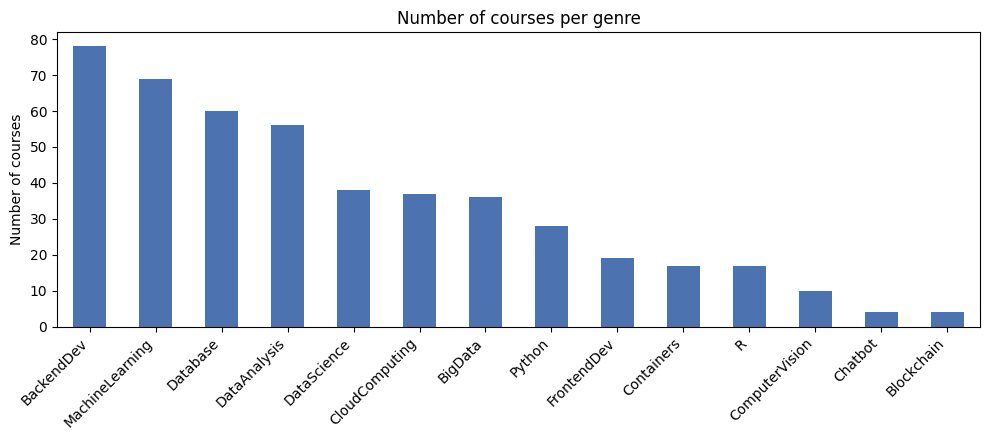

,0
BackendDev,78
MachineLearning,69
Database,60
DataAnalysis,56
DataScience,38
CloudComputing,37
BigData,36
Python,28
FrontendDev,19
Containers,17


In [2]:
genre_counts = course_df.iloc[:, 2:].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4.5))
genre_counts.plot(kind='bar', color='#4C72B0')
plt.title('Number of courses per genre')
plt.ylabel('Number of courses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/01_genre_counts.png', dpi=200)
plt.show()

genre_counts

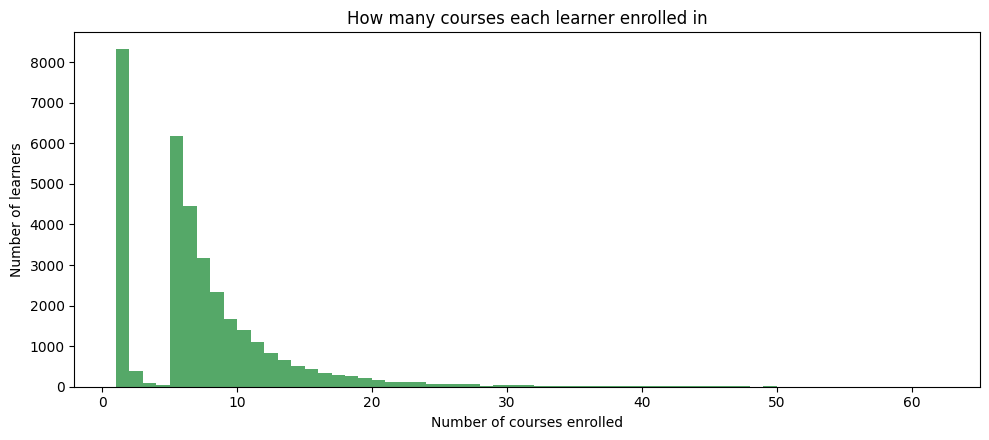

count    33901.0
mean         6.9
std          5.8
min          1.0
25%          2.0
50%          6.0
75%          9.0
max         61.0
dtype: float64
Learners with only 1 course: 8320


In [3]:
user_counts = ratings_df.groupby('user').size()

plt.figure(figsize=(10, 4.5))
plt.hist(user_counts, bins=range(1, user_counts.max() + 2), color='#55A868')
plt.title('How many courses each learner enrolled in')
plt.xlabel('Number of courses enrolled')
plt.ylabel('Number of learners')
plt.tight_layout()
plt.savefig('figures/02_enrollment_hist.png', dpi=200)
plt.show()

print(user_counts.describe().round(1))
print('Learners with only 1 course:', (user_counts == 1).sum())

Share of all enrollments in the top 20: 63.3 %


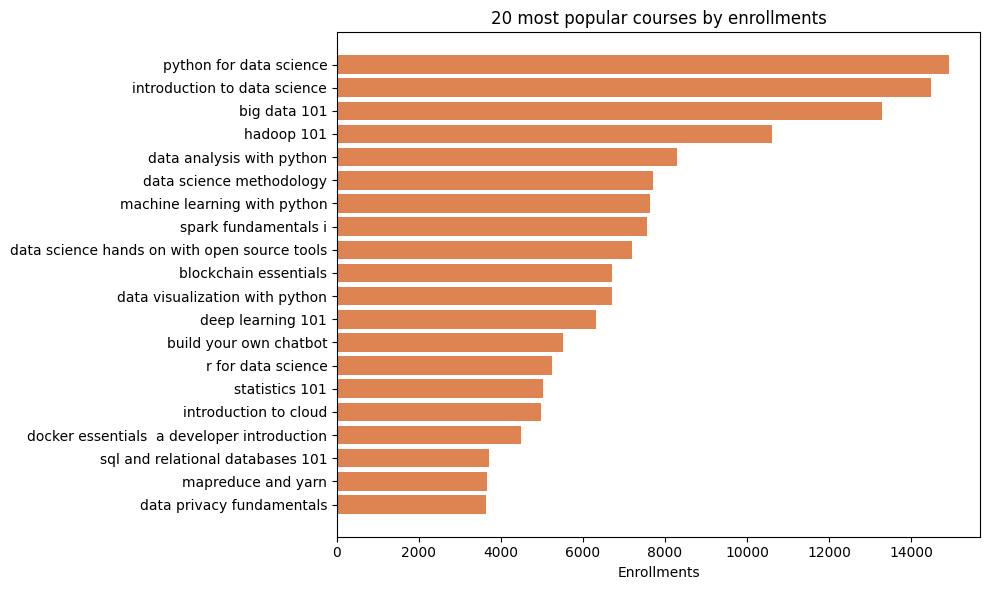

,COURSE_ID,TITLE,enrollments
1,PY0101EN,python for data science,14936
2,DS0101EN,introduction to data science,14477
3,BD0101EN,big data 101,13291
4,BD0111EN,hadoop 101,10599
5,DA0101EN,data analysis with python,8303
6,DS0103EN,data science methodology,7719
7,ML0101ENv3,machine learning with python,7644
8,BD0211EN,spark fundamentals i,7551
9,DS0105EN,data science hands on with open source tools,7199
10,BC0101EN,blockchain essentials,6719


In [4]:
top20 = (ratings_df.groupby('item').size().sort_values(ascending=False).head(20)
         .reset_index(name='enrollments')
         .merge(course_df[['COURSE_ID', 'TITLE']], left_on='item', right_on='COURSE_ID', how='left'))
top20 = top20[['COURSE_ID', 'TITLE', 'enrollments']]
top20.index = range(1, 21)

print('Share of all enrollments in the top 20:', round(top20['enrollments'].sum() / len(ratings_df) * 100, 1), '%')

plt.figure(figsize=(10, 6))
plt.barh(top20['TITLE'][::-1], top20['enrollments'][::-1], color='#DD8452')
plt.title('20 most popular courses by enrollments')
plt.xlabel('Enrollments')
plt.tight_layout()
plt.savefig('figures/03_top20_courses.png', dpi=200)
plt.show()

top20

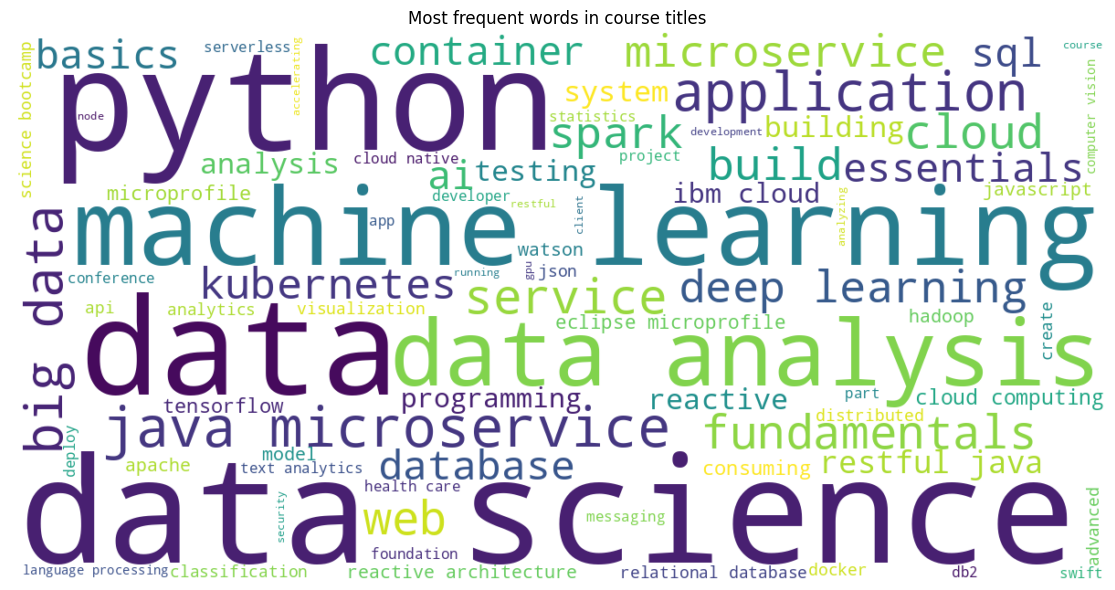

In [6]:
from wordcloud import WordCloud, STOPWORDS

titles = ' '.join(course_df['TITLE'].astype(str))
stopwords = set(STOPWORDS) | {'getting', 'started', 'using', 'enabling', 'template', 'university', 'end', 'introduction', 'basic'}

wc = WordCloud(width=1200, height=600, background_color='white', stopwords=stopwords,
               max_words=80, colormap='viridis', random_state=42).generate(titles)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most frequent words in course titles')
plt.tight_layout()
plt.savefig('figures/04_wordcloud.png', dpi=200)
plt.show()

In [7]:
profile_df = pd.read_csv(BASE + 'user_profile.csv')
test_df = pd.read_csv(BASE + 'rs_content_test.csv')

genre_matrix = course_df.set_index('COURSE_ID').iloc[:, 1:]
profile_matrix = profile_df.set_index('user')
test_users = test_df['user'].unique()

print(profile_df.shape, test_df.shape, 'Test users:', len(test_users))
profile_df.head(3)

(33901, 15) (9402, 3) Test users: 1000


,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0


In [8]:
def profile_recommendations(threshold):
    rows = []
    for user in test_users:
        seen = set(test_df.loc[test_df['user'] == user, 'item'])
        scores = pd.Series(genre_matrix.values @ profile_matrix.loc[user].values, index=genre_matrix.index)
        scores = scores[~scores.index.isin(seen)]
        scores = scores[scores >= threshold]
        rows += [(user, course, score) for course, score in scores.items()]
    return pd.DataFrame(rows, columns=['user', 'course', 'score'])

summary = []
for th in [10, 20, 30]:
    recs = profile_recommendations(th)
    summary.append({'threshold': th, 'avg_new_courses_per_user': round(len(recs) / len(test_users), 1)})
    if th == 10:
        recs_profile = recs

summary_profile = pd.DataFrame(summary)
summary_profile

,threshold,avg_new_courses_per_user
0,10,53.4
1,20,16.7
2,30,5.9


     COURSE_ID  times_recommended  \
1     TA0106EN                608   
2    GPXX0IBEN                548   
3   excourse22                547   
4   excourse21                547   
5     ML0122EN                544   
6   excourse06                533   
7   GPXX0TY1EN                533   
8   excourse04                533   
9   excourse31                524   
10  excourse72                516   

                                                TITLE  
1                             text analytics at scale  
2   data science in insurance  basic statistical a...  
3              introduction to data science in python  
4                  applied machine learning in python  
5                 accelerating deep learning with gpu  
6               sql for data science capstone project  
7   performing database operations in the cloudant...  
8                                sql for data science  
9   cloud computing applications  part 2  big data...  
10         foundations for big d

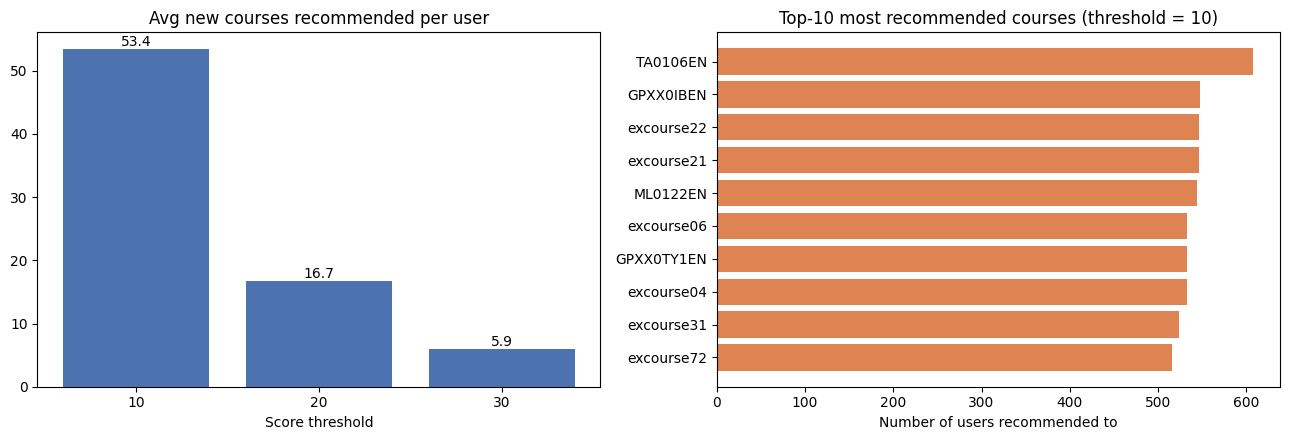

In [9]:
top10_profile = (recs_profile['course'].value_counts().head(10)
                 .rename_axis('COURSE_ID').reset_index(name='times_recommended')
                 .merge(course_df[['COURSE_ID', 'TITLE']], on='COURSE_ID', how='left'))
top10_profile.index = range(1, 11)
print(top10_profile)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(summary_profile['threshold'].astype(str), summary_profile['avg_new_courses_per_user'], color='#4C72B0')
ax[0].set_title('Avg new courses recommended per user'); ax[0].set_xlabel('Score threshold')
for i, v in enumerate(summary_profile['avg_new_courses_per_user']):
    ax[0].text(i, v, v, ha='center', va='bottom')
ax[1].barh(top10_profile['COURSE_ID'][::-1], top10_profile['times_recommended'][::-1], color='#DD8452')
ax[1].set_title('Top-10 most recommended courses (threshold = 10)'); ax[1].set_xlabel('Number of users recommended to')
plt.tight_layout()
plt.savefig('figures/05_profile_results.png', dpi=200)
plt.show()

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

text_df = pd.read_csv(BASE + 'course_processed.csv')
text_df['text'] = text_df['TITLE'].fillna('') + ' ' + text_df['DESCRIPTION'].fillna('')

vectorizer = CountVectorizer(stop_words='english', min_df=2)
bow = vectorizer.fit_transform(text_df['text'])

print('BoW matrix:', bow.shape)
print('Example words:', vectorizer.get_feature_names_out()[100:115])

BoW matrix: (307, 1358)
Example words: ['azure' 'backend' 'background' 'backup' 'badge' 'banking' 'base' 'based'
 'basic' 'basics' 'bayes' 'beautiful' 'begin' 'beginner' 'beginners']


In [11]:
sim_df = pd.DataFrame(cosine_similarity(bow), index=text_df['COURSE_ID'], columns=text_df['COURSE_ID'])

example = 'ML0101ENv3'
print('Most similar to:', text_df.set_index('COURSE_ID').loc[example, 'TITLE'])
print(sim_df[example].drop(example).sort_values(ascending=False).head(5).round(3)
      .to_frame('similarity').join(text_df.set_index('COURSE_ID')['TITLE']))

Most similar to: machine learning with python
            similarity                                              TITLE
COURSE_ID                                                                
ML0151EN         0.704                            machine learning with r
excourse47       0.628                           machine learning for all
excourse46       0.613                                   machine learning
ML0101EN         0.609                       machine learning with python
excourse60       0.538  introduction to tensorflow for artificial inte...


   threshold  avg_new_courses_per_user
0        0.5                      36.7
1        0.6                      17.3
2        0.7                       5.6 

     COURSE_ID  times_recommended                                     TITLE
1   excourse68                721  big data modeling and management systems
2   excourse32                718            introduction to data analytics
3   excourse04                677                      sql for data science
4   excourse23                677                data analysis using python
5   excourse36                677                data analysis using python
6   excourse64                672                 data science in real life
7     DS0110EN                600               data science with open data
8   excourse22                579    introduction to data science in python
9   excourse62                579    introduction to data science in python
10      TMP107                555         data science bootcamp with python


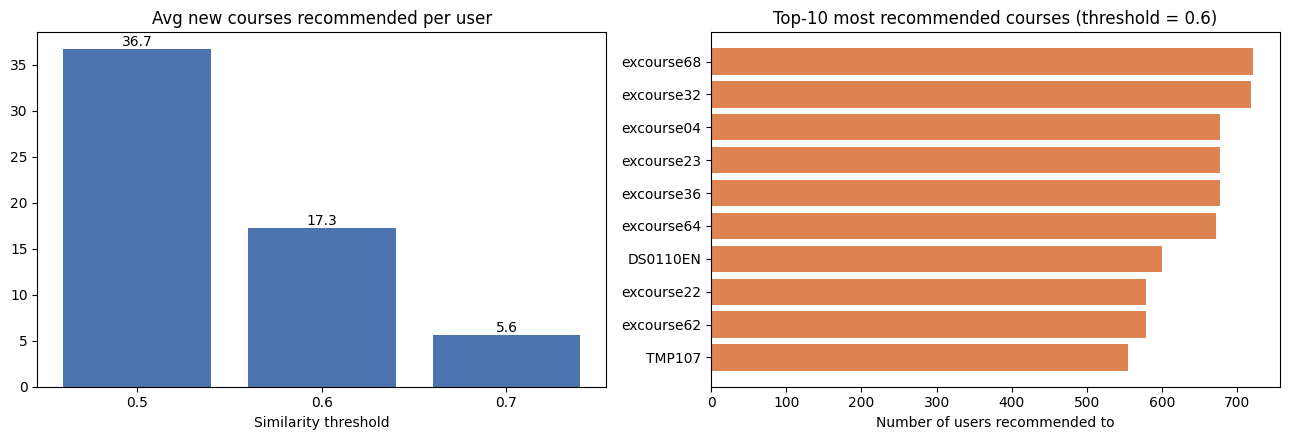

In [12]:
def similarity_recommendations(threshold):
    rows = []
    for user in test_users:
        seen = list(test_df.loc[test_df['user'] == user, 'item'])
        scores = sim_df.loc[seen].max(axis=0).drop(seen, errors='ignore')
        scores = scores[scores >= threshold]
        rows += [(user, course, score) for course, score in scores.items()]
    return pd.DataFrame(rows, columns=['user', 'course', 'similarity'])

summary = []
for th in [0.5, 0.6, 0.7]:
    recs = similarity_recommendations(th)
    summary.append({'threshold': th, 'avg_new_courses_per_user': round(len(recs) / len(test_users), 1)})
    if th == 0.6:
        recs_sim = recs
summary_sim = pd.DataFrame(summary)

top10_sim = (recs_sim['course'].value_counts().head(10)
             .rename_axis('COURSE_ID').reset_index(name='times_recommended')
             .merge(course_df[['COURSE_ID', 'TITLE']], on='COURSE_ID', how='left'))
top10_sim.index = range(1, 11)
print(summary_sim, '\n')
print(top10_sim)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(summary_sim['threshold'].astype(str), summary_sim['avg_new_courses_per_user'], color='#4C72B0')
ax[0].set_title('Avg new courses recommended per user'); ax[0].set_xlabel('Similarity threshold')
for i, v in enumerate(summary_sim['avg_new_courses_per_user']):
    ax[0].text(i, v, v, ha='center', va='bottom')
ax[1].barh(top10_sim['COURSE_ID'][::-1], top10_sim['times_recommended'][::-1], color='#DD8452')
ax[1].set_title('Top-10 most recommended courses (threshold = 0.6)'); ax[1].set_xlabel('Number of users recommended to')
plt.tight_layout()
plt.savefig('figures/06_similarity_results.png', dpi=200)
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

features = profile_df.drop(columns='user')
X_users = StandardScaler().fit_transform(features)

pca_full = PCA().fit(X_users)
cumvar = pca_full.explained_variance_ratio_.cumsum()
n_comp = int(np.argmax(cumvar >= 0.90) + 1)
print('Components needed for 90% variance:', n_comp)

X_pca_users = PCA(n_components=n_comp).fit_transform(X_users)

Components needed for 90% variance: 9


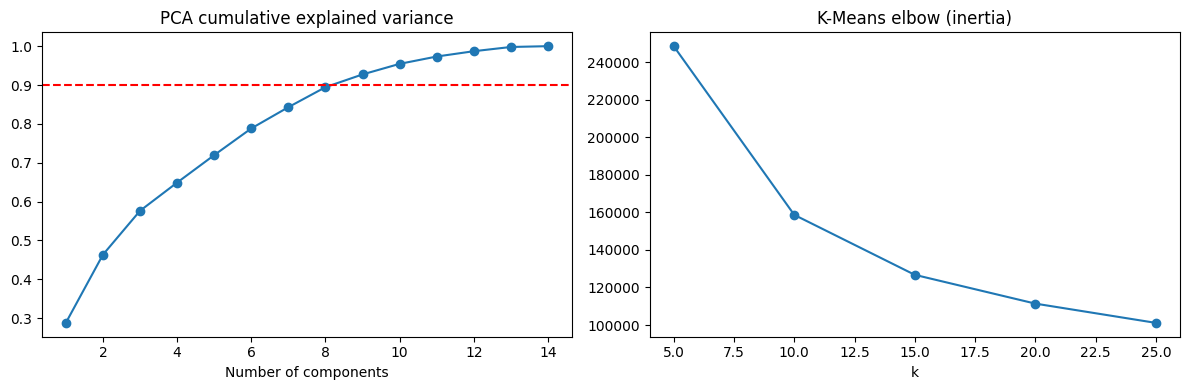

cluster
0     1042
1     2572
2      551
3     2547
4       20
5     2886
6     5056
7     1175
8      694
9     3849
10     316
11     176
12    8629
13    2077
14    2311
Name: count, dtype: int64


In [14]:
ks = [5, 10, 15, 20, 25]
inertias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca_users).inertia_ for k in ks]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, 15), cumvar, marker='o'); ax[0].axhline(0.9, color='red', linestyle='--')
ax[0].set_title('PCA cumulative explained variance'); ax[0].set_xlabel('Number of components')
ax[1].plot(ks, inertias, marker='o'); ax[1].set_title('K-Means elbow (inertia)'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.savefig('figures/07_pca_elbow.png', dpi=200); plt.show()

kmeans_users = KMeans(n_clusters=15, n_init=10, random_state=42).fit(X_pca_users)
cluster_df = pd.DataFrame({'user': profile_df['user'], 'cluster': kmeans_users.labels_})
print(cluster_df['cluster'].value_counts().sort_index())

   min_share_of_cluster  avg_new_courses_per_user
0                   0.1                      11.8
1                   0.2                       5.7
2                   0.3                       3.8 

     COURSE_ID  times_recommended  \
1     DS0101EN                418   
2     BD0101EN                383   
3     DS0105EN                349   
4     DS0103EN                325   
5     PY0101EN                311   
6     ST0101EN                306   
7     BD0111EN                242   
8   ML0101ENv3                224   
9     CC0101EN                203   
10    ML0115EN                191   

                                           TITLE  
1                   introduction to data science  
2                                   big data 101  
3   data science hands on with open source tools  
4                       data science methodology  
5                        python for data science  
6                                 statistics 101  
7                                

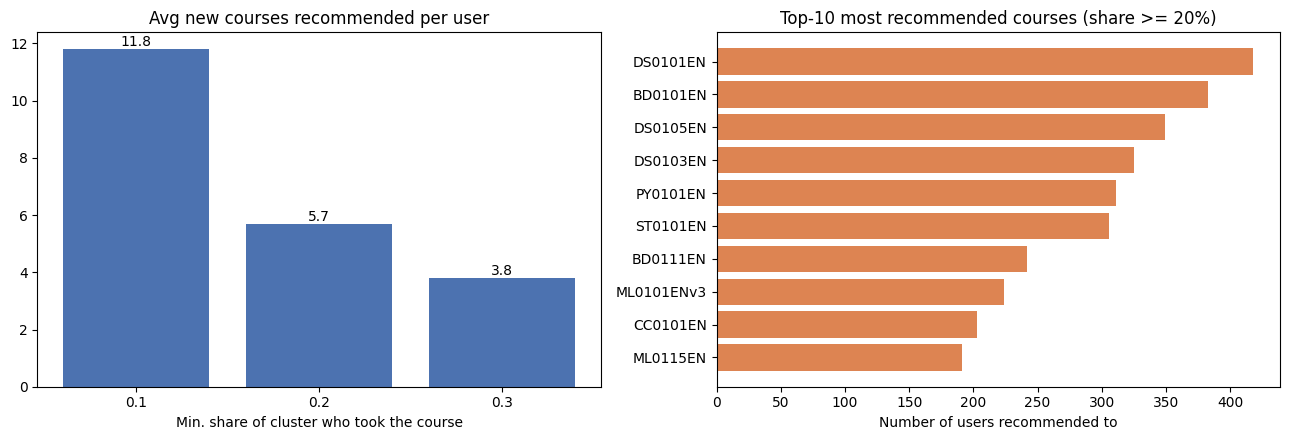

In [15]:
cluster_ratings = ratings_df.merge(cluster_df, on='user')
cluster_sizes = cluster_df['cluster'].value_counts()
course_share = (cluster_ratings.groupby(['cluster', 'item']).size()
                .div(cluster_sizes, level='cluster').rename('share').reset_index())

user_cluster = cluster_df.set_index('user')['cluster']

def cluster_recommendations(threshold):
    rows = []
    for user in test_users:
        c = user_cluster[user]
        seen = set(test_df.loc[test_df['user'] == user, 'item'])
        cand = course_share[(course_share['cluster'] == c) & (course_share['share'] >= threshold) & (~course_share['item'].isin(seen))]
        rows += [(user, course) for course in cand['item']]
    return pd.DataFrame(rows, columns=['user', 'course'])

summary = []
for th in [0.1, 0.2, 0.3]:
    recs = cluster_recommendations(th)
    summary.append({'min_share_of_cluster': th, 'avg_new_courses_per_user': round(len(recs) / len(test_users), 1)})
    if th == 0.2:
        recs_cluster = recs
summary_cluster = pd.DataFrame(summary)

top10_cluster = (recs_cluster['course'].value_counts().head(10)
                 .rename_axis('COURSE_ID').reset_index(name='times_recommended')
                 .merge(course_df[['COURSE_ID', 'TITLE']], on='COURSE_ID', how='left'))
top10_cluster.index = range(1, 11)
print(summary_cluster, '\n'); print(top10_cluster)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(summary_cluster['min_share_of_cluster'].astype(str), summary_cluster['avg_new_courses_per_user'], color='#4C72B0')
ax[0].set_title('Avg new courses recommended per user'); ax[0].set_xlabel('Min. share of cluster who took the course')
for i, v in enumerate(summary_cluster['avg_new_courses_per_user']):
    ax[0].text(i, v, v, ha='center', va='bottom')
ax[1].barh(top10_cluster['COURSE_ID'][::-1], top10_cluster['times_recommended'][::-1], color='#DD8452')
ax[1].set_title('Top-10 most recommended courses (share >= 20%)'); ax[1].set_xlabel('Number of users recommended to')
plt.tight_layout(); plt.savefig('figures/08_cluster_results.png', dpi=200); plt.show()

In [16]:
!pip install -q scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.3 MB/s eta 0:00:00


In [17]:
from surprise import Dataset, Reader, KNNBasic, accuracy
from surprise.model_selection import train_test_split as surprise_split

reader = Reader(rating_scale=(2, 3))
data = Dataset.load_from_df(ratings_df[['user', 'item', 'rating']], reader)

trainset, testset = surprise_split(data, test_size=0.3, random_state=42)

baseline_rmse = np.sqrt(np.mean([(r - trainset.global_mean) ** 2 for (_, _, r) in testset]))
print('Train ratings:', trainset.n_ratings, '| Test ratings:', len(testset))
print('Baseline RMSE (always predict the average rating):', round(baseline_rmse, 4))

cf_results = [{'model': 'Baseline (global mean)', 'rmse': baseline_rmse}]

Train ratings: 163314 | Test ratings: 69992
Baseline RMSE (always predict the average rating): 0.2115


In [18]:
for k in [10, 20, 40]:
    knn = KNNBasic(k=k, sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
    knn.fit(trainset)
    rmse = accuracy.rmse(knn.test(testset), verbose=False)
    print(f'Item-based KNN, k={k}: RMSE = {rmse:.4f}')
    cf_results.append({'model': f'KNN item-based (k={k})', 'rmse': rmse})

Item-based KNN, k=10: RMSE = 0.1933
Item-based KNN, k=20: RMSE = 0.1933
Item-based KNN, k=40: RMSE = 0.1933


In [19]:
from surprise import NMF

for n in [5, 15, 30]:
    nmf = NMF(n_factors=n, random_state=42, verbose=False)
    nmf.fit(trainset)
    rmse = accuracy.rmse(nmf.test(testset), verbose=False)
    print(f'NMF, {n} factors: RMSE = {rmse:.4f}')
    cf_results.append({'model': f'NMF ({n} factors)', 'rmse': rmse})

pd.DataFrame(cf_results).round(4)

NMF, 5 factors: RMSE = 0.3614
NMF, 15 factors: RMSE = 0.1986
NMF, 30 factors: RMSE = 0.1894


,model,rmse
0,Baseline (global mean),0.2115
1,KNN item-based (k=10),0.1933
2,KNN item-based (k=20),0.1933
3,KNN item-based (k=40),0.1933
4,NMF (5 factors),0.3614
5,NMF (15 factors),0.1986
6,NMF (30 factors),0.1894


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_cf = pd.DataFrame(trainset.build_testset(), columns=['user', 'item', 'rating'])
test_cf = pd.DataFrame(testset, columns=['user', 'item', 'rating'])

user_ids = {u: i for i, u in enumerate(ratings_df['user'].unique())}
item_ids = {c: i for i, c in enumerate(ratings_df['item'].unique())}

def encode(df):
    return [df['user'].map(user_ids).values, df['item'].map(item_ids).values]

global_mean = train_cf['rating'].mean()
print(len(train_cf), len(test_cf), '| users:', len(user_ids), '| courses:', len(item_ids))

163314 69992 | users: 33901 | courses: 126


In [21]:
def build_model(dim):
    user_in = keras.Input(shape=(1,), name='user')
    item_in = keras.Input(shape=(1,), name='course')

    user_vec = layers.Flatten()(layers.Embedding(len(user_ids), dim, embeddings_regularizer=keras.regularizers.l2(1e-6))(user_in))
    item_vec = layers.Flatten()(layers.Embedding(len(item_ids), dim, embeddings_regularizer=keras.regularizers.l2(1e-6))(item_in))
    user_bias = layers.Flatten()(layers.Embedding(len(user_ids), 1)(user_in))
    item_bias = layers.Flatten()(layers.Embedding(len(item_ids), 1)(item_in))

    dot = layers.Dot(axes=1)([user_vec, item_vec])
    rating = layers.Add()([dot, user_bias, item_bias])
    rating = layers.Lambda(lambda x: x + global_mean)(rating)

    model = keras.Model([user_in, item_in], rating)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

for dim in [8, 16, 32]:
    tf.random.set_seed(42)
    nn = build_model(dim)
    hist = nn.fit(encode(train_cf), train_cf['rating'].values, validation_split=0.1,
                  epochs=30, batch_size=512, verbose=0,
                  callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)])
    preds = np.clip(nn.predict(encode(test_cf), verbose=0).ravel(), 2, 3)
    rmse = np.sqrt(np.mean((preds - test_cf['rating'].values) ** 2))
    print(f'NN embedding, dim={dim}: RMSE = {rmse:.4f} (trained {len(hist.history["loss"])} epochs)')
    cf_results.append({'model': f'NN embedding (dim={dim})', 'rmse': rmse})

NN embedding, dim=8: RMSE = 0.1521 (trained 12 epochs)
NN embedding, dim=16: RMSE = 0.1552 (trained 9 epochs)
NN embedding, dim=32: RMSE = 0.1547 (trained 10 epochs)


                    model    rmse  improvement_vs_baseline_%
0  Baseline (global mean)  0.2115                        0.0
1   KNN item-based (k=10)  0.1933                        8.6
2   KNN item-based (k=20)  0.1933                        8.6
3   KNN item-based (k=40)  0.1933                        8.6
4         NMF (5 factors)  0.3614                      -70.9
5        NMF (15 factors)  0.1986                        6.1
6        NMF (30 factors)  0.1894                       10.4
7    NN embedding (dim=8)  0.1521                       28.1
8   NN embedding (dim=16)  0.1552                       26.6
9   NN embedding (dim=32)  0.1547                       26.9


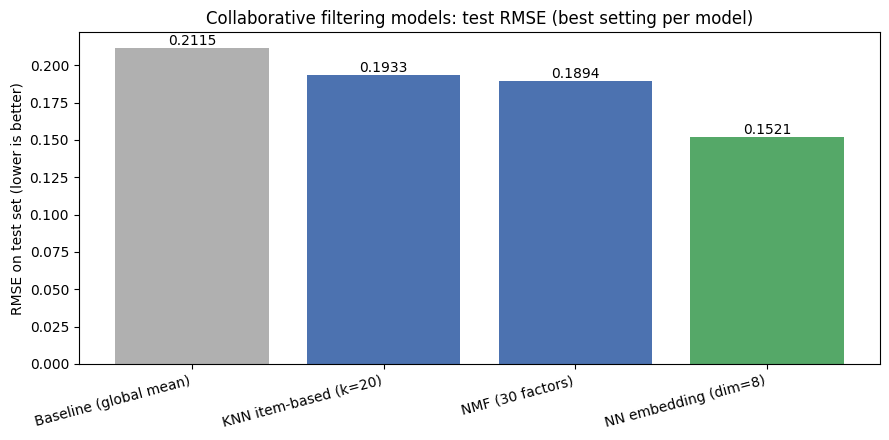

In [22]:
cf_df = pd.DataFrame(cf_results)
cf_df['improvement_vs_baseline_%'] = ((cf_df['rmse'].iloc[0] - cf_df['rmse']) / cf_df['rmse'].iloc[0] * 100).round(1)
print(cf_df.round(4))

best = cf_df.iloc[1:].copy()
best['family'] = best['model'].str.extract(r'^(KNN|NMF|NN)')[0]
best = best.loc[best.groupby('family')['rmse'].idxmin()]
plot_df = pd.concat([cf_df.iloc[[0]], best]).sort_values('rmse', ascending=False)

colors = ['#B0B0B0' if 'Baseline' in m else ('#55A868' if m.startswith('NN') else '#4C72B0') for m in plot_df['model']]
plt.figure(figsize=(9, 4.5))
bars = plt.bar(plot_df['model'], plot_df['rmse'], color=colors)
for b, v in zip(bars, plot_df['rmse']):
    plt.text(b.get_x() + b.get_width() / 2, v, f'{v:.4f}', ha='center', va='bottom')
plt.ylabel('RMSE on test set (lower is better)')
plt.title('Collaborative filtering models: test RMSE (best setting per model)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('figures/09_cf_rmse_comparison.png', dpi=200)
plt.show()

cf_df.to_csv('figures/cf_results.csv', index=False)

In [23]:
import shutil
from google.colab import files

shutil.make_archive('capstone_figures', 'zip', 'figures')
files.download('capstone_figures.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>